# # Data Engineering & ETL

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
from google.colab import drive
drive.mount('/content/drive')
folder = '/content/drive/MyDrive/E-Commerce ML Project'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
folder = '/content/drive/MyDrive/E-Commerce ML Project'
translation = pd.read_csv(folder + '/product_category_name_translation.csv')
sellers = pd.read_csv(folder + '/olist_sellers_dataset.csv')
order_items = pd.read_csv(folder + '/olist_order_items_dataset.csv')
orders = pd.read_csv(folder + '/olist_orders_dataset.csv')
reviews = pd.read_csv(folder + '/olist_order_reviews_dataset.csv')
payments = pd.read_csv(folder + '/olist_order_payments_dataset.csv')
geolocation = pd.read_csv(folder + '/olist_geolocation_dataset.csv')
customers = pd.read_csv(folder + '/olist_customers_dataset.csv')
products = pd.read_csv(folder + '/olist_products_dataset.csv')
print("All 9 datasets loaded successfully.")

All 9 datasets loaded successfully.


In [9]:
datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "translation": translation}
for name, data in datasets.items():
    print(f"{name}: {data.shape}")

customers: (99441, 5)
geolocation: (1000163, 5)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
orders: (99441, 8)
products: (32951, 9)
sellers: (3095, 4)
translation: (71, 2)


In [10]:
for name, df in datasets.items():
    print("\n")
    print(name.upper())
    df.info()



CUSTOMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


GEOLOCATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city     

In [11]:
for name, df in datasets.items():
    print("\n")
    print(name.upper())
    print(df.describe())



CUSTOMERS
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000


GEOLOCATION
       geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                 1.000163e+06     1.000163e+06     1.000163e+06
mean                  3.657417e+04    -2.117615e+01    -4.639054e+01
std                   3.054934e+04     5.715866e+00     4.269748e+00
min                   1.001000e+03    -3.660537e+01    -1.014668e+02
25%                   1.107500e+04    -2.360355e+01    -4.857317e+01
50%                   2.653000e+04    -2.291938e+01    -4.663788e+01
75%                   6.350400e+04    -1.997962e+01    -4.376771e+01
max                   9.999000e+04     4.506593e+01     1.211054e+02


ORDER_ITEMS
       order_item_id          price  freight_value


In [12]:
for name,df in datasets.items():
    print("\n")
    print(name.upper())
    print(df.isnull().sum())



CUSTOMERS
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


GEOLOCATION
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


ORDER_ITEMS
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


PAYMENTS
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


REVIEWS
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


ORDERS
order_id      

In [13]:
for name, df in datasets.items():
    print(f"{name:25} duplicates:",df.duplicated().sum())

customers                 duplicates: 0
geolocation               duplicates: 261831
order_items               duplicates: 0
payments                  duplicates: 0
reviews                   duplicates: 0
orders                    duplicates: 0
products                  duplicates: 0
sellers                   duplicates: 0
translation               duplicates: 0


In [14]:
customers = customers.drop_duplicates()
orders = orders.drop_duplicates()
order_items = order_items.drop_duplicates()
products = products.drop_duplicates()
sellers = sellers.drop_duplicates()
reviews = reviews.drop_duplicates()
payments = payments.drop_duplicates()
geolocation = geolocation.drop_duplicates()
translation = translation.drop_duplicates()

In [15]:
print(len(customers))
print(customers["customer_id"].nunique())

99441
99441


In [16]:
print(len(orders))
print(orders["order_id"].nunique())

99441
99441


In [17]:
print(len(products))
print(products["product_id"].nunique())

32951
32951


In [18]:
print(len(sellers))
print(sellers["seller_id"].nunique())

3095
3095


In [19]:
print(len(order_items))
print(order_items["order_id"].nunique())

112650
98666


In [20]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [21]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [22]:
order_items['price'] = pd.to_numeric(order_items['price'], errors='coerce')

In [23]:
order_items['freight_value'] = pd.to_numeric(order_items['freight_value'], errors='coerce')

In [24]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [25]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')

In [26]:
product_columns = ['product_name_lenght','product_description_lenght','product_photos_qty',
    'product_weight_g','product_length_cm','product_height_cm','product_width_cm']
for col in product_columns:
    products[col] = products[col].fillna(products[col].median())

In [27]:
sellers.columns

Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='object')

In [28]:
orders_customers = pd.merge( orders,customers,on='customer_id',how='left')
order_data = pd.merge( orders_customers, order_items, on='order_id', how='inner')
order_data = pd.merge( order_data, products[['product_id', 'product_category_name']], on='product_id', how='left')
order_data = pd.merge( order_data, sellers[['seller_id', 'seller_zip_code_prefix','seller_city', 'seller_state']], on='seller_id', how='left')
order_data = pd.merge( order_data, translation, on='product_category_name', how='left')
print("Merged dataset:", order_data.shape)

Merged dataset: (112650, 23)


# Feature Creation

In [29]:
order_data['item_total_value'] =(order_data['price'].fillna(0) + order_data['freight_value'].fillna(0))
final_data = order_data.copy()
final_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_id,shipping_limit_date,price,freight_value,product_category_name,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,item_total_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,9350,maua,SP,housewares,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,31570,belo horizonte,SP,perfumery,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,14840,guariba,SP,auto,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,31842,belo horizonte,MG,pet_shop,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,8752,mogi das cruzes,SP,stationery,28.62


# Dataset Export

In [30]:
final_data.to_csv('olist_final_analytical_dataset.csv', index=False)

#  Customer Analytics & RFM

In [31]:
print(final_data.shape)

(112650, 24)


In [32]:
print(final_data.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'product_category_name_english', 'item_total_value']


In [33]:
display(final_data.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_id,shipping_limit_date,price,freight_value,product_category_name,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,item_total_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,9350,maua,SP,housewares,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,31570,belo horizonte,SP,perfumery,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,14840,guariba,SP,auto,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,31842,belo horizonte,MG,pet_shop,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,8752,mogi das cruzes,SP,stationery,28.62


In [34]:
required_columns = ['customer_unique_id','order_id','order_purchase_timestamp','price','freight_value']
available_columns = [
    column
    for column in required_columns
    if column in final_data.columns
]

print("Available required columns:")
print(available_columns)

Available required columns:
['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'price', 'freight_value']


In [35]:
final_data['total_item_value'] = (final_data['price'] +final_data['freight_value'])
final_data[['price', 'freight_value', 'total_item_value'] ].head()

,price,freight_value,total_item_value
0,29.99,8.72,38.71
1,118.70,22.76,141.46
2,159.90,19.22,179.12
3,45.00,27.20,72.20
4,19.90,8.72,28.62


# Customer-Level Aggregation

In [36]:
customer_summary = ( final_data.groupby('customer_unique_id').agg(
  total_orders=( 'order_id', 'nunique'),
  total_items=(  'order_id', 'size'),
  total_spending=('total_item_value', 'sum'),
  first_purchase=('order_purchase_timestamp', 'min'),
  last_purchase=( 'order_purchase_timestamp', 'max')).reset_index())
customer_summary.head()

,customer_unique_id,total_orders,total_items,total_spending,first_purchase,last_purchase
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,1,1,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,1,1,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,1,1,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42


In [37]:
print(customer_summary.shape[0])

95420


In [38]:
print(round( customer_summary['total_orders'].mean(),2))

1.03


In [39]:
print( round(customer_summary['total_spending'].mean(),2))

166.04


In [40]:
print(round(customer_summary['total_spending'].sum(),2))

15843553.24


# Customer Spending Analysis and
#  Top Customers Visualization

In [41]:
top_customers = ( customer_summary.sort_values( by='total_spending',ascending=False).head(10))
top_customers

,customer_unique_id,total_orders,total_items,total_spending,first_purchase,last_purchase
3799,0a0a92112bd4c708ca5fde585afaa872,1,8,13664.08,2017-09-29 15:24:52,2017-09-29 15:24:52
81388,da122df9eeddfedc1dc1f5349a1a690c,2,2,7571.63,2017-04-01 15:58:40,2017-04-01 15:58:41
44139,763c8b1c9c68a0229c42c9fc6f662b93,1,4,7274.88,2018-07-15 14:49:44,2018-07-15 14:49:44
82230,dc4802a71eae9be1dd28f5d788ceb526,1,1,6929.31,2017-02-12 20:37:36,2017-02-12 20:37:36
26015,459bef486812aa25204be022145caa62,1,1,6922.21,2018-07-25 18:10:17,2018-07-25 18:10:17
95131,ff4159b92c40ebe40454e3e6a7c35ed6,1,1,6726.66,2017-05-24 18:14:34,2017-05-24 18:14:34
23947,4007669dec559734d6f53e029e360987,1,6,6081.54,2017-11-24 11:03:35,2017-11-24 11:03:35
34820,5d0a2980b292d049061542014e8960bf,1,2,4809.44,2018-07-12 12:08:36,2018-07-12 12:08:36
89056,eebb5dda148d3893cdaf5b5ca3040ccb,1,1,4764.34,2017-04-18 18:50:13,2017-04-18 18:50:13
27242,48e1ac109decbb87765a3eade6854098,1,1,4681.78,2018-06-22 12:23:19,2018-06-22 12:23:19


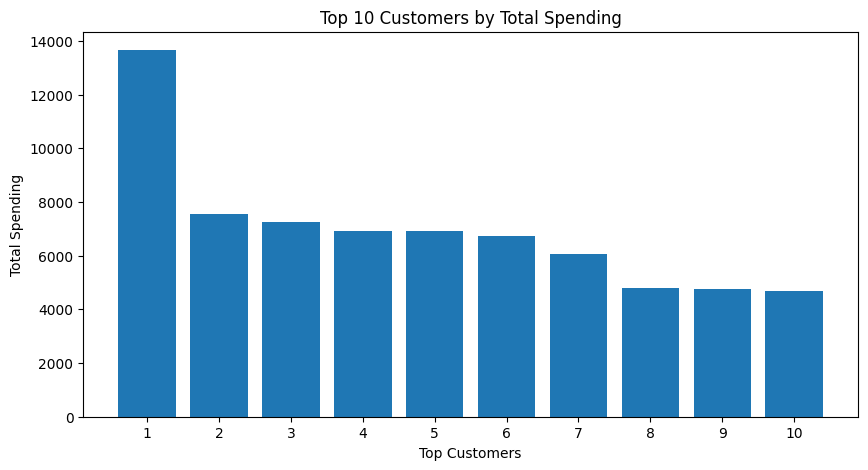

In [42]:
top_10_customers = (customer_summary.sort_values(by='total_spending', ascending=False).head(10))
plt.figure(figsize=(10, 5))
plt.bar( range(len(top_10_customers)), top_10_customers['total_spending'])
plt.xlabel('Top Customers')
plt.ylabel('Total Spending')
plt.title('Top 10 Customers by Total Spending')
plt.xticks(range(len(top_10_customers)), range(1, 11))
plt.show()

# RFM Customer Analysis

In [43]:
import pandas as pd

# Ensure the timestamp column is in datetime format
final_data['order_purchase_timestamp'] = pd.to_datetime(final_data['order_purchase_timestamp'])

# Calculate analysis date by adding 1 day to the maximum date in the dataset
analysis_date = (final_data['order_purchase_timestamp'].max() + pd.Timedelta(days=1))
print("RFM Analysis Date:", analysis_date)

RFM Analysis Date: 2018-09-04 09:06:57


In [44]:
rfm = (final_data.groupby('customer_unique_id').agg(
  Recency=('order_purchase_timestamp',
  lambda x: (analysis_date -x.max()).days),
   Frequency=('order_id', 'nunique'),
   Monetary=( 'total_item_value','sum')).reset_index())
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19
2,0000f46a3911fa3c0805444483337064,542,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89


In [45]:
print("RFM Dataset Shape:", rfm.shape)

RFM Dataset Shape: (95420, 4)


In [46]:
rfm.isnull().sum()

,0
customer_unique_id,0
Recency,0
Frequency,0
Monetary,0


In [47]:
rfm[[ 'Recency', 'Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,95420.000000,95420.000000,95420.000000
mean,243.600377,1.034018,166.040172
std,153.160320,0.211234,228.320333
min,1.000000,1.000000,9.590000
25%,119.000000,1.000000,63.100000
50%,224.000000,1.000000,107.940000
75%,353.000000,1.000000,183.220000
max,729.000000,16.000000,13664.080000


In [48]:
rfm['R_score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')

In [49]:
rfm['R_score'] = (rfm['R_score'].astype(int))
rfm['F_score'] = (rfm['F_score'].astype(int))
rfm['M_score'] = (rfm['M_score'].astype(int))

In [50]:
rfm['RFM_score'] = (rfm['R_score'] + rfm['F_score'] + rfm['M_score'])
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,4,1,4,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,4,1,1,6
2,0000f46a3911fa3c0805444483337064,542,1,86.22,1,1,2,4
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,2,1,1,4
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89,2,1,4,7


In [51]:
def assign_rfm_segment(score):
    if score >= 12:
        return 'Champions'
    elif score >= 9:
        return 'Loyal Customers'
    elif score >= 6:
        return 'Potential Customers'
    else:
        return 'At Risk'

In [52]:
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']
rfm['RFM_segment'] = rfm['RFM_score'].apply(assign_rfm_segment)
rfm.head(10)

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,4,1,4,9,Loyal Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,4,1,1,6,Potential Customers
2,0000f46a3911fa3c0805444483337064,542,1,86.22,1,1,2,4,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,2,1,1,4,At Risk
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89,2,1,4,7,Potential Customers
5,0004bd2a26a76fe21f786e4fbd80607f,151,1,166.98,4,1,4,9,Loyal Customers
6,00050ab1314c0e55a6ca13cf7181fecf,136,1,35.38,4,1,1,6,Potential Customers
7,00053a61a98854899e70ed204dd4bafe,187,1,419.18,3,1,5,9,Loyal Customers
8,0005e1862207bf6ccc02e4228effd9a0,548,1,150.12,1,1,4,6,Potential Customers
9,0005ef4cd20d2893f0d9fbd94d3c0d97,175,1,129.76,4,1,3,8,Potential Customers


In [53]:
rfm_segment_summary = (rfm.groupby('RFM_segment').agg(
 customer_count=('customer_unique_id','count'),
 average_recency=('Recency', 'mean'),
 average_frequency=( 'Frequency', 'mean'),
 average_monetary=('Monetary', 'mean')).reset_index())

In [54]:
rfm_segment_summary = (rfm_segment_summary.sort_values(by='customer_count',ascending=False))
rfm_segment_summary

,RFM_segment,customer_count,average_recency,average_frequency,average_monetary
2,Loyal Customers,38892,208.777872,1.022832,184.106424
3,Potential Customers,32682,304.014993,1.001652,107.269346
1,Champions,15827,120.472294,1.145574,298.599214
0,At Risk,8019,409.281207,1.000000,56.313715


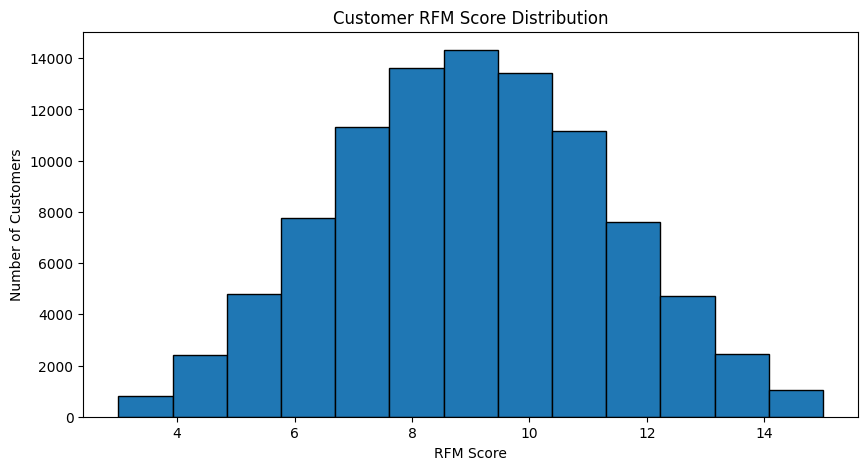

In [55]:
plt.figure(figsize=(10, 5))
plt.hist( rfm['RFM_score'], bins=13, edgecolor='black')
plt.xlabel('RFM Score')
plt.ylabel('Number of Customers')
plt.title('Customer RFM Score Distribution')
plt.show()

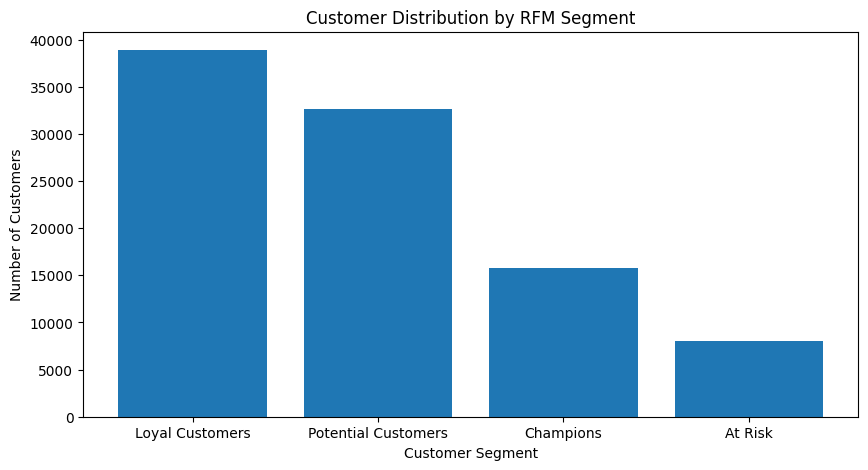

In [56]:
segment_counts = (rfm['RFM_segment'].value_counts())
plt.figure(figsize=(10, 5))
plt.bar(segment_counts.index,segment_counts.values)
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by RFM Segment')
plt.show()

In [57]:
rfm.to_csv('olist_customer_rfm_analysis.csv', index=False)

In [58]:
print(len(rfm))

95420


In [59]:
rfm['RFM_segment'].value_counts()

,count
RFM_segment,
Loyal Customers,38892
Potential Customers,32682
Champions,15827
At Risk,8019


In [60]:
rfm.head(10)

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,4,1,4,9,Loyal Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,4,1,1,6,Potential Customers
2,0000f46a3911fa3c0805444483337064,542,1,86.22,1,1,2,4,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,2,1,1,4,At Risk
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89,2,1,4,7,Potential Customers
5,0004bd2a26a76fe21f786e4fbd80607f,151,1,166.98,4,1,4,9,Loyal Customers
6,00050ab1314c0e55a6ca13cf7181fecf,136,1,35.38,4,1,1,6,Potential Customers
7,00053a61a98854899e70ed204dd4bafe,187,1,419.18,3,1,5,9,Loyal Customers
8,0005e1862207bf6ccc02e4228effd9a0,548,1,150.12,1,1,4,6,Potential Customers
9,0005ef4cd20d2893f0d9fbd94d3c0d97,175,1,129.76,4,1,3,8,Potential Customers


# Customer Segmentation

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [62]:
segmentation_data = rfm[['Recency', 'Frequency', 'Monetary']].copy()
segmentation_data = segmentation_data.replace( [np.inf, -np.inf], np.nan).dropna()

In [63]:
segmentation_data.shape

(95420, 3)

In [64]:
segmentation_data.head()

,Recency,Frequency,Monetary
0,116,1,141.90
1,119,1,27.19
2,542,1,86.22
3,326,1,43.62
4,293,1,196.89


In [65]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(segmentation_data)
len(segmentation_data)

95420

# Elbow Method

In [66]:
k_values = range(2, 9)
inertia_values = []
for k in k_values:
    kmeans = KMeans( n_clusters=k, random_state=42,n_init=10)
    kmeans.fit(scaled_features)
    inertia_values.append(kmeans.inertia_)

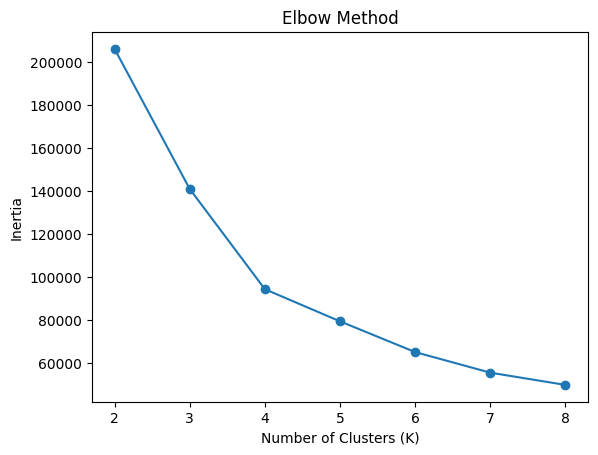

In [67]:
plt.plot(k_values, inertia_values , marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Silhouette Score

In [68]:
sample_size = min(10000, len(scaled_features))
random_state = np.random.RandomState(42)
sample_indices = random_state.choice( len(scaled_features),size=sample_size, replace=False)
sample_data = scaled_features[sample_indices]
len(sample_data)

10000

In [69]:
silhouette_values = []
for k in k_values:
    kmeans = KMeans( n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(sample_data)
    score = silhouette_score(sample_data,cluster_labels)

    silhouette_values.append(score)
silhouette_results = pd.DataFrame({'K': list(k_values),'Silhouette Score': silhouette_values})
display(silhouette_results)

,K,Silhouette Score
0,2,0.731520
1,3,0.457905
2,4,0.492453
3,5,0.504590
4,6,0.434742
5,7,0.436944
6,8,0.445979


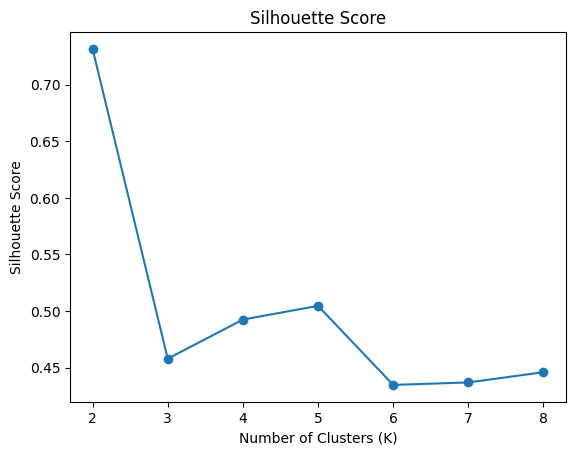

In [70]:
plt.plot( silhouette_results['K'], silhouette_results['Silhouette Score'], marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

In [71]:
best_k = silhouette_results.loc[ silhouette_results['Silhouette Score'].idxmax(), 'K']
best_k

np.int64(2)

In [72]:
final_kmeans = KMeans( n_clusters=int(best_k),random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(scaled_features)

In [73]:
rfm['cluster'] = final_kmeans.fit_predict(scaled_features)

In [74]:
segmentation_output = rfm.loc[segmentation_data.index].copy()
segmentation_output['cluster'] = cluster_labels
display(segmentation_output.head())

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_segment,cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,4,1,4,9,Loyal Customers,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,4,1,1,6,Potential Customers,0
2,0000f46a3911fa3c0805444483337064,542,1,86.22,1,1,2,4,At Risk,0
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,2,1,1,4,At Risk,0
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89,2,1,4,7,Potential Customers,0


In [75]:
cluster_summary = segmentation_output.groupby('cluster').agg(
 customers=('customer_unique_id', 'count'),
 average_recency=('Recency', 'mean'),
 average_frequency=('Frequency', 'mean'),
 average_monetary=('Monetary', 'mean')).round(2)
cluster_summary

,customers,average_recency,average_frequency,average_monetary
cluster,,,,
0,92496,244.15,1.00,160.75
1,2924,226.21,2.11,333.54


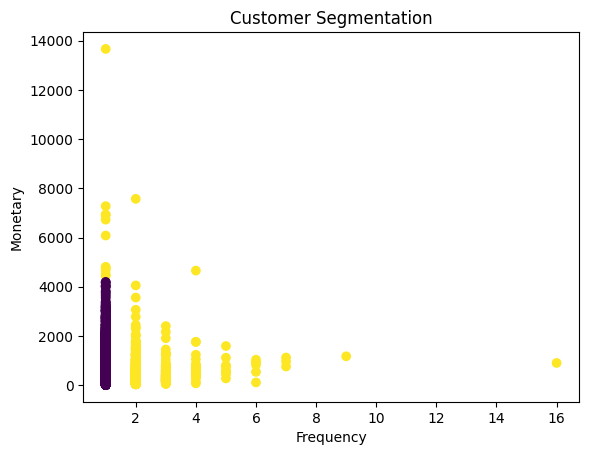

In [76]:
plt.scatter(segmentation_output['Frequency'], segmentation_output['Monetary'], c=segmentation_output['cluster'])
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Segmentation')
plt.show()

In [77]:
segmentation_output.to_csv( 'olist_customer_segmentation.csv', index=False)

# Sales / Demand Forecasting

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [79]:
sales_data = final_data[['order_purchase_timestamp', 'item_total_value']].copy()
sales_data = sales_data.dropna()

In [80]:
sales_data['purchase_date'] = ( sales_data['order_purchase_timestamp'].dt.normalize())

In [81]:
daily_sales = sales_data.groupby('purchase_date')['item_total_value'].sum()
daily_sales = daily_sales.sort_index()
daily_sales = daily_sales.asfreq( 'D', fill_value=0)
daily_sales = daily_sales.to_frame('daily_sales')
display(daily_sales.head())

,daily_sales
purchase_date,
2016-09-04,136.23
2016-09-05,75.06
2016-09-06,0.00
2016-09-07,0.00
2016-09-08,0.00


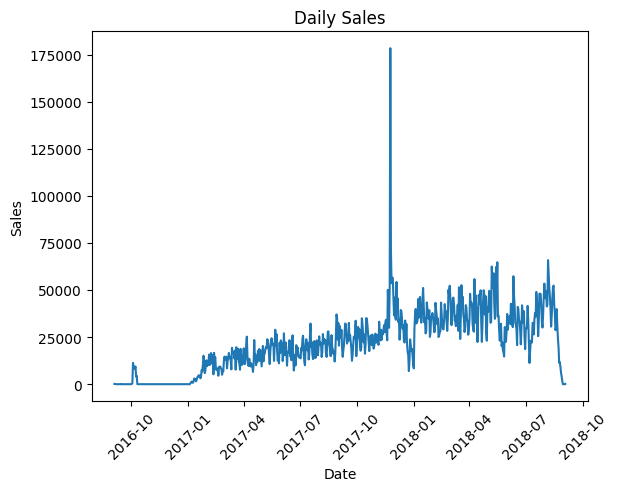

In [82]:
plt.plot( daily_sales.index, daily_sales['daily_sales'])
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Daily Sales')
plt.xticks(rotation=45)
plt.show()

In [83]:
test_size = 30
train_data = daily_sales.iloc[:-test_size]
test_data = daily_sales.iloc[-test_size:]

In [84]:
model = ExponentialSmoothing(train_data['daily_sales'], trend=None, seasonal=None,initialization_method='estimated')
fitted_model = model.fit()
test_forecast = fitted_model.forecast(len(test_data))
test_forecast = pd.Series(test_forecast, index=test_data.index)
test_forecast = test_forecast.clip(lower=0)
test_forecast.head()

,0
purchase_date,
2018-08-05,45010.95773
2018-08-06,45010.95773
2018-08-07,45010.95773
2018-08-08,45010.95773
2018-08-09,45010.95773


In [85]:
mae = mean_absolute_error( test_data['daily_sales'], test_forecast)
rmse = mean_squared_error( test_data['daily_sales'],  test_forecast) ** 0.5
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 21513.89
RMSE: 26840.58


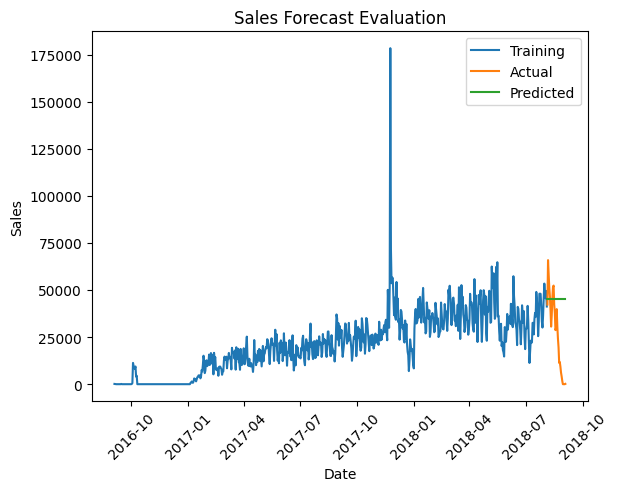

In [86]:
plt.plot(train_data.index, train_data['daily_sales'], label='Training')
plt.plot(test_data.index, test_data['daily_sales'],label='Actual')
plt.plot(test_forecast.index, test_forecast,label='Predicted')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales Forecast Evaluation')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [87]:
final_model = ExponentialSmoothing( daily_sales['daily_sales'], trend=None, seasonal=None, initialization_method='estimated')
final_fitted_model = final_model.fit()
future_sales = final_fitted_model.forecast(30)
future_sales = future_sales.clip(lower=0)

In [88]:
print(future_sales.min())
print(future_sales.max())
print(future_sales.mean())

632.9491659438308
632.9491659438308
632.9491659438311


In [89]:
future_dates = pd.date_range( start=daily_sales.index.max() + pd.Timedelta(days=1), periods=30,freq='D')
sales_forecast = pd.DataFrame({ 'Date': future_dates,'Predicted Sales': future_sales.values})
sales_forecast['Predicted Sales'] = sales_forecast[ 'Predicted Sales'].clip(lower=0)
sales_forecast.head(10)

,Date,Predicted Sales
0,2018-09-04,632.949166
1,2018-09-05,632.949166
2,2018-09-06,632.949166
3,2018-09-07,632.949166
4,2018-09-08,632.949166
5,2018-09-09,632.949166
6,2018-09-10,632.949166
7,2018-09-11,632.949166
8,2018-09-12,632.949166
9,2018-09-13,632.949166


In [90]:
print(daily_sales.columns)
print(daily_sales.head())

Index(['daily_sales'], dtype='object')
               daily_sales
purchase_date             
2016-09-04          136.23
2016-09-05           75.06
2016-09-06            0.00
2016-09-07            0.00
2016-09-08            0.00


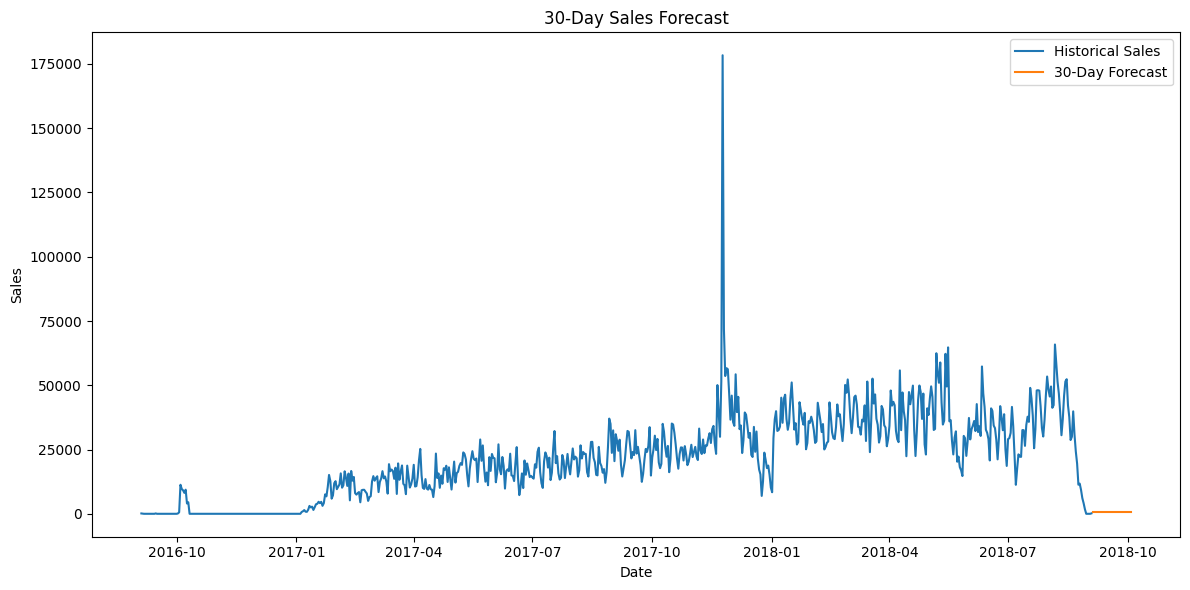

In [91]:
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales['daily_sales'], label='Historical Sales')
plt.plot(sales_forecast['Date'],sales_forecast['Predicted Sales'], label='30-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('30-Day Sales Forecast')
plt.legend()
plt.tight_layout()
plt.show()

In [92]:
sales_forecast.to_csv('olist_sales_forecast.csv',index=False)

# ML Model / API Integration

In [93]:
!pip -q install fastapi uvicorn nest-asyncio joblib streamlit plotly requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 49.0 MB/s eta 0:00:00


In [94]:
# Deployment paths — keep all runtime paths consistent.
import os
import sys
import time
import json
import shutil
import socket
import subprocess
from pathlib import Path

PROJECT_ROOT = Path("/content")
API_DIR = PROJECT_ROOT / "api"
API_MODEL_DIR = PROJECT_ROOT / "api_models"
DASHBOARD_DIR = PROJECT_ROOT / "dashboard"
DASHBOARD_PAGES_DIR = DASHBOARD_DIR / "dashboard_pages"

API_DIR.mkdir(parents=True, exist_ok=True)
API_MODEL_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_PAGES_DIR.mkdir(parents=True, exist_ok=True)

# Artifacts created by the ML sections above.
ARTIFACTS = [
    "olist_final_analytical_dataset.csv",
    "olist_customer_rfm_analysis.csv",
    "olist_customer_segmentation.csv",
    "olist_sales_forecast.csv",
]

# Model artifacts are copied from the existing ML objects when available.
if "scaler" in globals() and "final_kmeans" in globals():
    import joblib
    joblib.dump(scaler, API_MODEL_DIR / "segmentation_scaler.pkl")
    joblib.dump(final_kmeans, API_MODEL_DIR / "segmentation_kmeans.pkl")
    print("Saved trained segmentation models to:", API_MODEL_DIR)
else:
    # Fall back to previously saved files if the notebook was resumed.
    for name in ["segmentation_scaler.pkl", "segmentation_kmeans.pkl"]:
        candidates = [
            PROJECT_ROOT / name,
            Path(folder) / "api_models" / name if "folder" in globals() else PROJECT_ROOT / name,
            Path(folder) / name if "folder" in globals() else PROJECT_ROOT / name,
        ]
        for candidate in candidates:
            if candidate.exists():
                shutil.copy2(candidate, API_MODEL_DIR / name)
                break

# Copy analytical outputs into the standard runtime root.
for name in ARTIFACTS:
    source = PROJECT_ROOT / name
    if not source.exists() and "folder" in globals():
        drive_source = Path(folder) / name
        if drive_source.exists():
            shutil.copy2(drive_source, source)

# Forecast is also kept beside the API models for a self-contained API.
forecast_source = PROJECT_ROOT / "olist_sales_forecast.csv"
if forecast_source.exists():
    shutil.copy2(forecast_source, API_MODEL_DIR / "sales_forecast.csv")

print("\nDeployment artifact check:")
for path in [
    PROJECT_ROOT / "olist_final_analytical_dataset.csv",
    PROJECT_ROOT / "olist_customer_rfm_analysis.csv",
    PROJECT_ROOT / "olist_customer_segmentation.csv",
    PROJECT_ROOT / "olist_sales_forecast.csv",
    API_MODEL_DIR / "segmentation_scaler.pkl",
    API_MODEL_DIR / "segmentation_kmeans.pkl",
    API_MODEL_DIR / "sales_forecast.csv",
]:
    print(f"{'READY' if path.exists() else 'MISSING'}: {path}")

Saved trained segmentation models to: /content/api_models

Deployment artifact check:
READY: /content/olist_final_analytical_dataset.csv
READY: /content/olist_customer_rfm_analysis.csv
READY: /content/olist_customer_segmentation.csv
READY: /content/olist_sales_forecast.csv
READY: /content/api_models/segmentation_scaler.pkl
READY: /content/api_models/segmentation_kmeans.pkl
READY: /content/api_models/sales_forecast.csv


In [95]:
# Create a single, self-contained FastAPI application.
# It does not depend on Google Drive paths, so the API can run from /content/api.
api_main = r'''
import os
from pathlib import Path

import joblib
import pandas as pd
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field


BASE_DIR = Path(os.environ.get("API_MODEL_DIR", "/content/api_models"))
SCALER_PATH = BASE_DIR / "segmentation_scaler.pkl"
MODEL_PATH = BASE_DIR / "segmentation_kmeans.pkl"
FORECAST_PATH = BASE_DIR / "sales_forecast.csv"


app = FastAPI(
    title="E-Commerce Customer Intelligence API",
    description="Customer segmentation and sales forecasting API",
    version="1.1.0",
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=False,
    allow_methods=["*"],
    allow_headers=["*"],
)


class CustomerInput(BaseModel):
    recency: float = Field(..., ge=0)
    frequency: float = Field(..., ge=0)
    monetary: float = Field(..., ge=0)


class ForecastInput(BaseModel):
    days: int = Field(default=30, ge=1)


def _load_models():
    if not SCALER_PATH.exists():
        raise HTTPException(
            status_code=500,
            detail=f"Missing scaler: {SCALER_PATH}",
        )
    if not MODEL_PATH.exists():
        raise HTTPException(
            status_code=500,
            detail=f"Missing KMeans model: {MODEL_PATH}",
        )

    return joblib.load(SCALER_PATH), joblib.load(MODEL_PATH)


@app.get("/")
def home():
    return {
        "message": "E-Commerce Customer Intelligence API",
        "status": "running",
        "version": "1.1.0",
        "endpoints": [
            "/health",
            "/predict/segment",
            "/predict/forecast",
            "/docs",
        ],
    }


@app.get("/health")
def health():
    required = [SCALER_PATH, MODEL_PATH, FORECAST_PATH]
    missing = [str(p) for p in required if not p.exists()]

    if missing:
        return {
            "status": "degraded",
            "missing_files": missing,
        }

    return {
        "status": "healthy",
        "models_ready": True,
        "forecast_ready": True,
    }


@app.post("/predict/segment")
def predict_segment(customer: CustomerInput):
    scaler, model = _load_models()

    customer_df = pd.DataFrame(
        [[customer.recency, customer.frequency, customer.monetary]],
        columns=["Recency", "Frequency", "Monetary"],
    )

    try:
        scaled = scaler.transform(customer_df)
        cluster = int(model.predict(scaled)[0])
    except Exception as exc:
        raise HTTPException(status_code=500, detail=str(exc))

    return {
        "recency": customer.recency,
        "frequency": customer.frequency,
        "monetary": customer.monetary,
        "predicted_cluster": cluster,
    }


@app.post("/predict/forecast")
def predict_forecast(request: ForecastInput):
    if not FORECAST_PATH.exists():
        raise HTTPException(
            status_code=500,
            detail=f"Missing forecast file: {FORECAST_PATH}",
        )

    forecast = pd.read_csv(FORECAST_PATH)

    if forecast.empty:
        raise HTTPException(
            status_code=500,
            detail="Forecast file is empty.",
        )

    days = min(request.days, len(forecast))
    result = forecast.head(days).copy()

    if "Date" in result.columns:
        result["Date"] = pd.to_datetime(
            result["Date"], errors="coerce"
        ).astype(str)

    return {
        "days_requested": request.days,
        "days_returned": len(result),
        "forecast": result.to_dict(orient="records"),
    }
'''

api_main_path = API_DIR / "main.py"
api_main_path.write_text(api_main.strip() + "\n", encoding="utf-8")

print("FastAPI application written to:", api_main_path)

FastAPI application written to: /content/api/main.py


In [96]:
import requests
import subprocess
import sys
import time
import os

def free_port(port):
    result = subprocess.run(
        ["fuser", "-k", f"{port}/tcp"],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    time.sleep(1)

free_port(8000)

api_env = os.environ.copy()
api_env["API_MODEL_DIR"] = str(API_MODEL_DIR)

api_process = subprocess.Popen(
    [
        sys.executable, "-m", "uvicorn", "main:app",
        "--host", "0.0.0.0",
        "--port", "8000",
        "--log-level", "info",
    ],
    cwd=str(API_DIR),
    env=api_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

api_local_url = "http://127.0.0.1:8000"

for _ in range(20):
    try:
        response = requests.get(api_local_url + "/health", timeout=2)
        if response.status_code == 200:
            break
    except Exception:
        pass
    time.sleep(1)
else:
    output = api_process.stdout.read() if api_process.stdout else ""
    raise RuntimeError("FastAPI did not start.\n" + output)

print("FastAPI is RUNNING")
print("Local API:", api_local_url)
print("Health:", requests.get(api_local_url + "/health", timeout=5).json())
print("Docs:", api_local_url + "/docs")

FastAPI is RUNNING
Local API: http://127.0.0.1:8000
Health: {'status': 'healthy', 'models_ready': True, 'forecast_ready': True}
Docs: http://127.0.0.1:8000/docs


In [97]:
import requests

segment_payload = {
    "recency": 100,
    "frequency": 2,
    "monetary": 250,
}

segment_response = requests.post(
    api_local_url + "/predict/segment",
    json=segment_payload,
    timeout=10,
)
print("Segment endpoint:", segment_response.status_code)
print(segment_response.json())

forecast_response = requests.post(
    api_local_url + "/predict/forecast",
    json={"days": 7},
    timeout=10,
)
print("\nForecast endpoint:", forecast_response.status_code)
print(forecast_response.json())

Segment endpoint: 200
{'recency': 100.0, 'frequency': 2.0, 'monetary': 250.0, 'predicted_cluster': 1}

Forecast endpoint: 200
{'days_requested': 7, 'days_returned': 7, 'forecast': [{'Date': '2018-09-04', 'Predicted Sales': 632.9491659438308}, {'Date': '2018-09-05', 'Predicted Sales': 632.9491659438308}, {'Date': '2018-09-06', 'Predicted Sales': 632.9491659438308}, {'Date': '2018-09-07', 'Predicted Sales': 632.9491659438308}, {'Date': '2018-09-08', 'Predicted Sales': 632.9491659438308}, {'Date': '2018-09-09', 'Predicted Sales': 632.9491659438308}, {'Date': '2018-09-10', 'Predicted Sales': 632.9491659438308}]}


In [98]:
import shutil
import subprocess
import os

if shutil.which("cloudflared") is None:
    deb_path = "/content/cloudflared-linux-amd64.deb"
    subprocess.run(
        [
            "wget", "-q",
            "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb",
            "-O", deb_path,
        ],
        check=True,
    )
    subprocess.run(["dpkg", "-i", deb_path], check=False)

print("cloudflared:", shutil.which("cloudflared"))

cloudflared: /usr/local/bin/cloudflared


In [99]:
import re
import subprocess
import time

api_tunnel = None
api_public_url = None

if shutil.which("cloudflared"):
    api_tunnel = subprocess.Popen(
        [
            "cloudflared", "tunnel", "--url",
            api_local_url, "--no-autoupdate"
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    api_tunnel_output = []
    deadline = time.time() + 25

    while time.time() < deadline:
        line = api_tunnel.stdout.readline()
        if line:
            api_tunnel_output.append(line)
            match = re.search(
                r"https://[a-zA-Z0-9.-]+\.trycloudflare\.com",
                line,
            )
            if match:
                api_public_url = match.group(0).rstrip("/")
                break
        elif api_tunnel.poll() is not None:
            break
        else:
            time.sleep(0.2)

    if api_public_url:
        print("PUBLIC API URL:", api_public_url)
        print("PUBLIC API DOCS:", api_public_url + "/docs")
    else:
        print("Tunnel started, but a public URL was not detected yet.")
        print("The local API is still working:", api_local_url)
else:
    print("cloudflared is unavailable; skipping public API tunnel.")

PUBLIC API URL: https://relay-roller-portrait-benchmark.trycloudflare.com
PUBLIC API DOCS: https://relay-roller-portrait-benchmark.trycloudflare.com/docs


# Business Intelligence Dashboard

In [100]:
# Write the dashboard files in one consistent directory.
import textwrap

(DASHBOARD_PAGES_DIR / "__init__.py").write_text("", encoding="utf-8")

dashboard_config = '''
import os
from pathlib import Path

BASE_DIR = Path(os.environ.get("DASHBOARD_BASE_DIR", "/content"))
MODEL_DIR = BASE_DIR / "api_models"

def data_path(filename):
    return BASE_DIR / filename

def model_path(filename):
    return MODEL_DIR / filename
'''

dashboard_loader = '''
import pandas as pd
from config import data_path

REQUIRED = {
    "data": "olist_final_analytical_dataset.csv",
    "segmentation": "olist_customer_segmentation.csv",
    "rfm": "olist_customer_rfm_analysis.csv",
    "forecast": "olist_sales_forecast.csv",
}

def load_data():
    paths = {name: data_path(filename) for name, filename in REQUIRED.items()}
    missing = [str(path) for path in paths.values() if not path.exists()]

    if missing:
        raise FileNotFoundError(
            "Missing dashboard data files: " + ", ".join(missing)
        )

    data = pd.read_csv(paths["data"])
    segmentation = pd.read_csv(paths["segmentation"])
    rfm = pd.read_csv(paths["rfm"])
    forecast = pd.read_csv(paths["forecast"])

    if "order_purchase_timestamp" in data.columns:
        data["order_purchase_timestamp"] = pd.to_datetime(
            data["order_purchase_timestamp"], errors="coerce"
        )

    if "Date" in forecast.columns:
        forecast["Date"] = pd.to_datetime(
            forecast["Date"], errors="coerce"
        )

    return data, segmentation, rfm, forecast
'''

overview = '''
import streamlit as st

def show_overview(data):
    st.header("📊 Business Overview")

    total_revenue = data["item_total_value"].sum()
    total_orders = data["order_id"].nunique()
    total_customers = data["customer_unique_id"].nunique()

    average_order_value = (
        data.groupby("order_id")["item_total_value"].sum().mean()
    )

    c1, c2, c3, c4 = st.columns(4)

    c1.metric("Total Revenue", f"₹{total_revenue:,.2f}")
    c2.metric("Total Orders", f"{total_orders:,}")
    c3.metric("Total Customers", f"{total_customers:,}")
    c4.metric("Average Order Value", f"₹{average_order_value:,.2f}")
'''

segmentation_page = '''
import streamlit as st
import plotly.express as px

def show_segmentation(segmentation, rfm):
    st.header("👥 Customer Segmentation")

    cluster_summary = (
        segmentation.groupby("cluster")
        .agg(
            customers=("customer_unique_id", "nunique"),
            revenue=("Monetary", "sum"),
        )
        .reset_index()
    )

    c1, c2 = st.columns(2)

    with c1:
        fig = px.bar(
            cluster_summary,
            x="cluster",
            y="customers",
            title="Customers by Cluster",
        )
        st.plotly_chart(fig, use_container_width=True)

    with c2:
        fig = px.bar(
            cluster_summary,
            x="cluster",
            y="revenue",
            title="Revenue by Cluster",
        )
        st.plotly_chart(fig, use_container_width=True)

    st.divider()
    st.subheader("🎯 RFM Customer Segments")

    rfm_summary = (
        rfm.groupby("RFM_segment")
        .agg(
            customers=("customer_unique_id", "nunique"),
            revenue=("Monetary", "sum"),
        )
        .reset_index()
        .sort_values("customers", ascending=False)
    )

    fig = px.bar(
        rfm_summary,
        x="RFM_segment",
        y="customers",
        title="Customers by RFM Segment",
    )

    st.plotly_chart(fig, use_container_width=True)
'''

sales_page = '''
import streamlit as st
import pandas as pd
import plotly.express as px

def show_sales_analytics(data):
    st.header("📈 Sales Analytics")

    valid = data.dropna(
        subset=["order_purchase_timestamp", "item_total_value"]
    ).copy()

    daily_sales = (
        valid.assign(
            order_date=valid["order_purchase_timestamp"].dt.normalize()
        )
        .groupby("order_date", as_index=False)["item_total_value"]
        .sum()
    )

    fig = px.line(
        daily_sales,
        x="order_date",
        y="item_total_value",
        title="Daily Sales",
    )

    st.plotly_chart(fig, use_container_width=True)

    st.divider()
    st.subheader("🛒 Top Product Categories")

    if "product_category_name_english" in data.columns:
        category_sales = (
            data.dropna(subset=["product_category_name_english"])
            .groupby("product_category_name_english")["item_total_value"]
            .sum()
            .reset_index()
            .sort_values("item_total_value", ascending=False)
            .head(10)
        )

        fig = px.bar(
            category_sales.sort_values("item_total_value"),
            x="item_total_value",
            y="product_category_name_english",
            orientation="h",
            title="Top 10 Product Categories",
        )

        st.plotly_chart(fig, use_container_width=True)
'''

prediction_page = '''
import os
import joblib
import pandas as pd
import streamlit as st
from config import model_path

def show_prediction():
    st.header("🤖 ML Customer Segmentation Prediction")

    c1, c2, c3 = st.columns(3)

    recency = c1.number_input(
        "Recency",
        min_value=0.0,
        value=100.0
    )

    frequency = c2.number_input(
        "Frequency",
        min_value=0.0,
        value=1.0
    )

    monetary = c3.number_input(
        "Monetary",
        min_value=0.0,
        value=100.0
    )

    if st.button("Predict Customer Segment"):
        scaler_file = model_path("segmentation_scaler.pkl")
        model_file = model_path("segmentation_kmeans.pkl")

        if not scaler_file.exists() or not model_file.exists():
            st.error("Segmentation model files are missing.")
            return

        scaler = joblib.load(scaler_file)
        model = joblib.load(model_file)

        customer = pd.DataFrame(
            [[recency, frequency, monetary]],
            columns=["Recency", "Frequency", "Monetary"],
        )

        cluster = int(
            model.predict(scaler.transform(customer))[0]
        )

        st.success(f"Predicted Customer Cluster: {cluster}")
'''

forecast_page = '''
import streamlit as st
import plotly.express as px

def show_forecast(forecast):
    st.header("🔮 Sales Forecast")

    fig = px.line(
        forecast,
        x="Date",
        y="Predicted Sales",
        title="30-Day Sales Forecast",
        markers=True,
    )

    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Forecast Data")
    st.dataframe(forecast, use_container_width=True)
'''

# Main Streamlit application
app_code = '''
import streamlit as st

from data_loader import load_data
from dashboard_pages.overview import show_overview
from dashboard_pages.segmentation import show_segmentation
from dashboard_pages.sales_analytics import show_sales_analytics
from dashboard_pages.prediction import show_prediction
from dashboard_pages.forecast import show_forecast

st.set_page_config(
    page_title="E-Commerce Customer Intelligence",
    page_icon="📊",
    layout="wide",
)

st.title("📊 E-Commerce Customer Intelligence Dashboard")

try:
    data, segmentation, rfm, forecast = load_data()

except Exception as error:
    st.error(f"Error loading dashboard data: {error}")
    st.stop()


page = st.sidebar.radio(
    "Navigation",
    [
        "Overview",
        "Prediction",
        "Sales Analytics",
        "Segmentation",
        "Forecast"
    ]
)


if page == "Overview":
    show_overview(data)

elif page == "Prediction":
    show_prediction()

elif page == "Sales Analytics":
    show_sales_analytics(data)

elif page == "Segmentation":
    show_segmentation(segmentation, rfm)

elif page == "Forecast":
    show_forecast(forecast)
'''

dashboard_files = {
    DASHBOARD_DIR / "config.py": dashboard_config,
    DASHBOARD_DIR / "data_loader.py": dashboard_loader,
    DASHBOARD_PAGES_DIR / "overview.py": overview,
    DASHBOARD_PAGES_DIR / "segmentation.py": segmentation_page,
    DASHBOARD_PAGES_DIR / "sales_analytics.py": sales_page,
    DASHBOARD_PAGES_DIR / "prediction.py": prediction_page,
    DASHBOARD_PAGES_DIR / "forecast.py": forecast_page,
    DASHBOARD_DIR / "app.py": app_code,
}

for path, content in dashboard_files.items():
    path.write_text(
        textwrap.dedent(content).strip() + "\n",
        encoding="utf-8"
    )

print("Dashboard created at:", DASHBOARD_DIR)

for path in dashboard_files:
    print("READY:", path)

Dashboard created at: /content/dashboard
READY: /content/dashboard/config.py
READY: /content/dashboard/data_loader.py
READY: /content/dashboard/dashboard_pages/overview.py
READY: /content/dashboard/dashboard_pages/segmentation.py
READY: /content/dashboard/dashboard_pages/sales_analytics.py
READY: /content/dashboard/dashboard_pages/prediction.py
READY: /content/dashboard/dashboard_pages/forecast.py
READY: /content/dashboard/app.py


In [101]:
# Start exactly one Streamlit process and verify it before creating its public tunnel.
import requests
import subprocess
import sys
import os
import time

free_port(8501)

dashboard_env = os.environ.copy()
dashboard_env["DASHBOARD_BASE_DIR"] = str(PROJECT_ROOT)

dashboard_process = subprocess.Popen(
    [
        sys.executable, "-m", "streamlit", "run",
        str(DASHBOARD_DIR / "app.py"),
        "--server.port", "8501",
        "--server.address", "0.0.0.0",
        "--server.headless", "true",
        "--browser.gatherUsageStats", "false",
    ],
    cwd=str(DASHBOARD_DIR),
    env=dashboard_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

dashboard_local_url = "http://127.0.0.1:8501"

for _ in range(25):
    try:
        response = requests.get(dashboard_local_url, timeout=2)
        if response.status_code == 200:
            break
    except Exception:
        pass
    time.sleep(1)
else:
    output = dashboard_process.stdout.read() if dashboard_process.stdout else ""
    raise RuntimeError("Streamlit did not start.\n" + output)

print("Streamlit dashboard is RUNNING")
print("Local dashboard:", dashboard_local_url)

Streamlit dashboard is RUNNING
Local dashboard: http://127.0.0.1:8501


In [102]:
import requests

# Ensure the local URL is defined in this scope
dashboard_local_url = "http://127.0.0.1:8501"
dashboard_response = requests.get(dashboard_local_url, timeout=10)

print("Dashboard HTTP status:", dashboard_response.status_code)
print("Dashboard check:", "PASS" if dashboard_response.status_code == 200 else "CHECK LOGS")

print("\nDeployment structure:")
for path in [
    API_DIR / "main.py",
    API_MODEL_DIR / "segmentation_scaler.pkl",
    API_MODEL_DIR / "segmentation_kmeans.pkl",
    API_MODEL_DIR / "sales_forecast.csv",
    DASHBOARD_DIR / "app.py",
    DASHBOARD_DIR / "data_loader.py",
    DASHBOARD_PAGES_DIR / "overview.py",
    DASHBOARD_PAGES_DIR / "segmentation.py",
    DASHBOARD_PAGES_DIR / "sales_analytics.py",
    DASHBOARD_PAGES_DIR / "prediction.py",
    DASHBOARD_PAGES_DIR / "forecast.py",
]:
    print(f"{'✓' if path.exists() else '✗'} {path}")

Dashboard HTTP status: 200
Dashboard check: PASS

Deployment structure:
✓ /content/api/main.py
✓ /content/api_models/segmentation_scaler.pkl
✓ /content/api_models/segmentation_kmeans.pkl
✓ /content/api_models/sales_forecast.csv
✓ /content/dashboard/app.py
✓ /content/dashboard/data_loader.py
✓ /content/dashboard/dashboard_pages/overview.py
✓ /content/dashboard/dashboard_pages/segmentation.py
✓ /content/dashboard/dashboard_pages/sales_analytics.py
✓ /content/dashboard/dashboard_pages/prediction.py
✓ /content/dashboard/dashboard_pages/forecast.py


In [103]:
import re
import subprocess
import time
import shutil

dashboard_tunnel = None
dashboard_public_url = None
dashboard_local_url = "http://127.0.0.1:8501"

if shutil.which("cloudflared"):
    dashboard_tunnel = subprocess.Popen(
        [
            "cloudflared", "tunnel", "--url",
            dashboard_local_url, "--no-autoupdate"
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    deadline = time.time() + 25

    while time.time() < deadline:
        line = dashboard_tunnel.stdout.readline()
        if line:
            match = re.search(
                r"https://[a-zA-Z0-9.-]+\.trycloudflare\.com",
                line,
            )
            if match:
                dashboard_public_url = match.group(0).rstrip("/")
                break
        elif dashboard_tunnel.poll() is not None:
            break
        else:
            time.sleep(0.2)

    if dashboard_public_url:
        print("PUBLIC DASHBOARD URL:", dashboard_public_url)
    else:
        print("Dashboard tunnel started, but a public URL was not detected yet.")
        print("The local dashboard is still working:", dashboard_local_url)
else:
    print("cloudflared is unavailable; skipping public dashboard tunnel.")

PUBLIC DASHBOARD URL: https://est-findlaw-scenario-regions.trycloudflare.com
